In [2]:
!kaggle --version

Kaggle API 1.7.4.5


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  

cuda


In [4]:
!kaggle competitions download -c us-patent-phrase-to-phrase-matching


  0%|          | 0.00/682k [00:00<?, ?B/s]
100%|##########| 682k/682k [00:00<00:00, 180MB/s]


In [5]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU count: 1
Current device: 0


In [6]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Panshul\Desktop\panshul\download\uspatent DATASET\train.csv")
print(df.shape)
print(df.head())
print(df['score'].describe())

(36473, 5)
                 id     anchor                  target context  score
0  37d61fd2272659b1  abatement  abatement of pollution     A47   0.50
1  7b9652b17b68b7a4  abatement          act of abating     A47   0.75
2  36d72442aefd8232  abatement         active catalyst     A47   0.25
3  5296b0c19e1ce60e  abatement     eliminating process     A47   0.50
4  54c1e3b9184cb5b6  abatement           forest region     A47   0.00
count    36473.000000
mean         0.362062
std          0.258335
min          0.000000
25%          0.250000
50%          0.250000
75%          0.500000
max          1.000000
Name: score, dtype: float64


In [7]:
print(df.isnull().sum())

id         0
anchor     0
target     0
context    0
score      0
dtype: int64


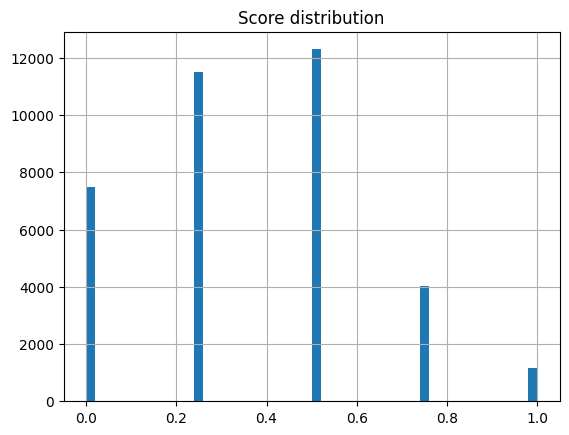

In [8]:
import matplotlib.pyplot as plt
df['score'].hist(bins=50)
plt.title("Score distribution")
plt.show()

In [9]:
def clean_text(s):
    if not isinstance(s, str):
        return ""
    return " ".join(s.split()).strip()

df['anchor'] = df['anchor'].apply(clean_text)
df['target'] = df['target'].apply(clean_text)

In [10]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"  # or "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
encoded = tokenizer(
    list(df['anchor'].values[:8]),
    list(df['target'].values[:8]),
    padding='max_length',       
    truncation=True,
    max_length=128,              
    return_tensors='pt'
)

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class PatentDataset(Dataset):
    def __init__(self, anchors, targets, scores, tokenizer, max_len=128):
        self.anchors = anchors
        self.targets = targets
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.scores)

    def __getitem__(self, idx):
        a = str(self.anchors[idx])
        b = str(self.targets[idx])
        encoded = self.tokenizer(
            a, b,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item['labels'] = torch.tensor(self.scores[idx], dtype=torch.float)
        return item

In [13]:
train_dataset = PatentDataset(df['anchor'].values, df['target'].values, df['score'].values, tokenizer, max_len=128)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

In [14]:
from transformers import AutoModel
import torch.nn as nn

class SimilarityModel(nn.Module):
    def __init__(self, model_name, dropout=0.2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size//2, 1)   
        )
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, return_dict=True)
        pooled = outputs.pooler_output if getattr(outputs, "pooler_output", None) is not None else outputs.last_hidden_state[:,0]
        out = self.regressor(pooled)
        return out.squeeze(1)  # shape (batch,)


In [15]:
criterion = nn.MSELoss()

In [16]:
from scipy.stats import spearmanr

def spearman_corr(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW  # optional, PyTorch version
from transformers import AutoModel, get_linear_schedule_with_warmup, AutoTokenizer
from tqdm import tqdm
import numpy as np
from scipy.stats import spearmanr
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimilarityModel(MODEL_NAME).to(device)
criterion = torch.nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 3
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler()

best_spearman = -1.0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for batch in pbar:
        # Move all tensors to GPU
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        labels = batch.pop('labels')

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            # Handle token_type_ids for RoBERTa
            token_type_ids = batch.get('token_type_ids', None)
            outputs = model(input_ids=batch['input_ids'],
                            attention_mask=batch['attention_mask'],
                            token_type_ids=token_type_ids)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{epoch_loss / (pbar.n+1):.4f}"})
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

    # ----------------------------
    # 9️⃣ Save Checkpoint
    # ----------------------------
    ckpt_path = f"checkpoint_epoch{epoch+1}.pt"
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict()
    }, ckpt_path)
    print("Saved checkpoint:", ckpt_path)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Panshul\AppData\Local\Temp\ipykernel_33316\3751602859.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1:   0%|                                                                                | 0/2280 [00:00<?, ?it/s]

In [ ]:
def evaluate(model, val_loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Valid"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch.get('token_type_ids')
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            preds.extend(outputs.detach().cpu().numpy().tolist())
            trues.extend(labels.detach().cpu().numpy().tolist())
    import numpy as np
    preds = np.array(preds)
    trues = np.array(trues)
    spearman = spearmanr(trues, preds).correlation
    return spearman

val_spearman = evaluate(model, val_loader)
print("Validation Spearman:", val_spearman)

In [ ]:
def predict_single(model, tokenizer, anchor, target, max_len=128):
    model.eval()
    encoded = tokenizer(anchor, target, padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    for k in encoded:
        encoded[k] = encoded[k].to(device)
    with torch.no_grad():
        score = model(encoded['input_ids'], encoded['attention_mask'], encoded.get('token_type_ids'))
    return float(score.detach().cpu().numpy())

print(predict_single(model, tokenizer, "A method for ...", "A technique for ..."))

In [ ]:
accumulation_steps = 4
optimizer.zero_grad()
for idx, batch in enumerate(train_loader):
    # compute loss
    loss = ...
    loss = loss / accumulation_steps
    scaler.scale(loss).backward()
    if (idx + 1) % accumulation_steps == 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
